## 1. Problem Framing

# Causal / explanatory pipeline 1 (new): Recurring donation behavior

## Problem framing
**Business question:** What supporter-level factors are **associated with** becoming a **recurring donor**?

**Data constraint:** This notebook uses **only** `lighthouse_csv_v7/donations.csv` and `lighthouse_csv_v7/supporters.csv`.

## Target definition
We create a new column in the donations-derived dataset called **`recurring_donation`** defined as **True** if either:
- The `supporter_id` appears **more than once** in `donations` (repeat donor), **OR**
- Any donation row for that supporter has `is_recurring == True`.

Because `donations` contains multiple rows per supporter, we build a **supporter-level** modeling table (one row per supporter) where the label is computed from the donations history.

**Approach:** Explanatory OLS (linear probability model) to estimate conditional associations. Logistic regression is a common alternative for binary outcomes.

**Textbook alignment (*My Educator Machine Learning*)**: Explanatory MLR (Ch. 9–10), residual and **normality** diagnostics, **VIF** for multicollinearity. **Prediction vs. explanation** (Ch. 1): here we prioritize interpretable associations. **Correlation is not causation**—defend claims modestly.

## Deployment notes (Ch. 17)
Use results to prioritize **stewardship strategies** by acquisition channel/type; validate with A/B tests before operational automation.

**Approach type (textbook framing):** This is an **explanatory/causal relationship** analysis (not a prediction pipeline). We use regression + diagnostics to understand *associations* that can inform decisions and future experiments.

## 2. Data Acquisition, Preparation & Exploration

This section loads the relevant tables, explains any joins, and explores distributions, missingness, and correlations. The goal is to make the modeling choices reproducible and understandable to non-technical stakeholders.

In [9]:
import matplotlib.pyplot as plt

# Quick EDA helpers (kept lightweight so notebook runs fast)

def report_missing(df, name='df'):
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    print(f"Missingness ({name}):")
    display(miss.to_frame('pct_missing').head(30))


def numeric_overview(df, name='df'):
    num = df.select_dtypes(include=['number'])
    print(f"Numeric overview ({name}):")
    display(num.describe().T)


def corr_heatmap(df, name='df', max_cols=25):
    num = df.select_dtypes(include=['number'])
    if num.shape[1] == 0:
        print('No numeric columns for correlation.')
        return
    cols = list(num.columns[:max_cols])
    c = num[cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 8))
    plt.imshow(c, aspect='auto')
    plt.xticks(range(len(cols)), cols, rotation=90)
    plt.yticks(range(len(cols)), cols)
    plt.title(f"Correlation heatmap (first {len(cols)} numeric cols) - {name}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()


In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats as scipy_stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path


def find_project_root(marker_dir="lighthouse_csv_v7"):
    """Walk upward from CWD until marker_dir is found."""
    p = Path.cwd().resolve()
    for cand in [p] + list(p.parents):
        if (cand / marker_dir).exists():
            return cand
    raise FileNotFoundError(
        f"Could not find {marker_dir}/ by walking up from {Path.cwd().resolve()}"
    )


PROJECT_ROOT = find_project_root("lighthouse_csv_v7")
DATA_DIR = PROJECT_ROOT / "lighthouse_csv_v7"


VIF_THRESHOLD = 7.0

def prepare_features(df, label_col, extra_drop=None):
    extra_drop = extra_drop or []
    d = df.copy()
    for c in extra_drop:
        if c in d.columns:
            d = d.drop(columns=[c])
    y = d[label_col]
    X = d.drop(columns=[label_col])

    # Drop ID-like columns before any modeling/tests
    _id_cols = [c for c in X.columns if str(c).lower() == "id" or str(c).lower().endswith("_id")]
    X = X.drop(columns=_id_cols, errors="ignore")

    # bool → int
    for c in X.select_dtypes(include=[bool]).columns:
        X[c] = X[c].astype(int)

    # median/mode imputations
    num_cols = list(X.select_dtypes(include=[np.number]).columns)
    cat_cols = [c for c in X.columns if c not in num_cols]
    for c in num_cols:
        if X[c].isna().any():
            X[c] = X[c].fillna(X[c].median())
    for c in cat_cols:
        if X[c].isna().any():
            m = X[c].mode()
            X[c] = X[c].fillna(m.iloc[0] if len(m) else "Unknown")

    # dummies
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    bool_cols = X.select_dtypes(include=[bool]).columns
    X[bool_cols] = X[bool_cols].astype(int)

    X = X.select_dtypes(include=[np.number])
    nz = X.std(numeric_only=True) > 0
    X = X.loc[:, nz[nz].index]
    return X, y

def ols_fit(X, y):
    Xc = sm.add_constant(X, has_constant="add")
    return sm.OLS(y, Xc).fit(), Xc

def vif_series(X_with_const):
    arr = np.asarray(X_with_const, dtype=float)
    out = []
    for i in range(arr.shape[1]):
        out.append(variance_inflation_factor(arr, i))
    return pd.Series(out, index=X_with_const.columns)

def remove_high_vif_one_at_a_time(X, y, threshold=VIF_THRESHOLD, max_iter=300):
    Xw = X.copy()
    removed = []
    for _ in range(max_iter):
        if Xw.shape[1] == 0:
            break
        Xc = sm.add_constant(Xw, has_constant="add")
        try:
            v = vif_series(Xc)
        except (np.linalg.LinAlgError, ValueError):
            Xw = Xw.loc[:, ~Xw.columns.duplicated()]
            continue
        vv = v.drop("const", errors="ignore")
        if vv.empty or vv.max() <= threshold:
            break
        worst = vv.idxmax()
        if worst not in Xw.columns:
            break
        Xw = Xw.drop(columns=[worst])
        removed.append((worst, float(vv.max())))
    return Xw, removed

def shapiro_tail(x, max_n=5000):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 3:
        return np.nan, np.nan
    if len(x) > max_n:
        rng = np.random.default_rng(42)
        x = rng.choice(x, size=max_n, replace=False)
    return scipy_stats.shapiro(x)

def plot_top_t(model, k=5, title="Top features by |t| (OLS)"):
    t = model.tvalues.drop("const", errors="ignore").dropna()
    top_idx = t.abs().sort_values(ascending=False).head(k).index
    top = t.loc[top_idx].sort_values()
    plt.figure(figsize=(8, 4))
    colors = ["#1f77b4" if v > 0 else "#d62728" for v in top.values]
    plt.barh(top.index, top.values, color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("t-statistic")
    plt.tight_layout()
    plt.show()


def plot_top_t_positive(model, k=5, title="Top features by t (most positive)"):
    t = model.tvalues.drop("const", errors="ignore").dropna()
    top = t.sort_values(ascending=False).head(k)
    plt.figure(figsize=(8, 4))
    plt.barh(top.index[::-1], top.values[::-1], color="#1f77b4")
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("t-statistic")
    plt.tight_layout()
    plt.show()

supporters = pd.read_csv(DATA_DIR / "supporters.csv")
donations = pd.read_csv(DATA_DIR / "donations.csv")
donations["donation_date"] = pd.to_datetime(donations["donation_date"], errors="coerce")
donations["is_recurring"] = donations["is_recurring"].fillna(False).astype(bool)

supporters.shape, donations.shape

((60, 15), (420, 13))

## 1) Create the label: `recurring_donation`
We compute the label at the **supporter** level, but we do **not** keep any other engineered donation-history columns in the modeling table.

Definition:
- `recurring_donation` is **True** if (`supporter_id` appears more than once in `donations`) **OR** (any row has `is_recurring == True`).

In [3]:
# Compute supporter-level recurring_donation (ONLY new column kept)

donor_counts = donations.groupby("supporter_id")["donation_id"].count()
any_rec = donations.groupby("supporter_id")["is_recurring"].any()

supporters_labeled = supporters.copy()

supporters_labeled["recurring_donation"] = (
    (supporters_labeled["supporter_id"].map(donor_counts).fillna(0) > 1)
    | supporters_labeled["supporter_id"].map(any_rec).fillna(False).astype(bool)
).astype(int)

print("Supporters:", supporters_labeled.shape[0])
print("Recurring rate:", supporters_labeled["recurring_donation"].mean())
supporters_labeled[["supporter_id", "recurring_donation"]].head()


Supporters: 60
Recurring rate: 0.9666666666666667


,supporter_id,recurring_donation
0,1,1
1,2,1
2,3,1
3,4,1
4,5,1


## 2) Initial MLR (Linear Probability Model)
We regress `recurring_donation` on **supporter attributes only** (type, channel, geography, status). No other engineered donation-history features are included.

In [4]:
label = "recurring_donation"
drop_extra = [
    "supporter_id","display_name","organization_name","first_name","last_name","email","phone",
    "created_at","first_donation_date",
]

X, y = prepare_features(supporters_labeled.dropna(subset=["acquisition_channel"]), label, extra_drop=drop_extra)
m0, _ = ols_fit(X, y)
print(m0.summary())


                            OLS Regression Results                            
Dep. Variable:     recurring_donation   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                 -0.061
Method:                 Least Squares   F-statistic:                    0.8013
Date:                Tue, 07 Apr 2026   Prob (F-statistic):              0.682
Time:                        13:56:02   Log-Likelihood:                 26.344
No. Observations:                  60   AIC:                            -16.69
Df Residuals:                      42   BIC:                             21.01
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

## 3) Normality diagnostics
For binary outcomes, normality of the label is not expected; we still examine residual behavior and proceed with VIF-based refinement.

Label skew: -5.333750171636798 Shapiro p (subsample): 1.2324066341227882e-16
Residual JB: (np.float64(665.89725353287), np.float64(2.5249259048973503e-145), np.float64(-3.3917158873169218), np.float64(17.843987158847717))


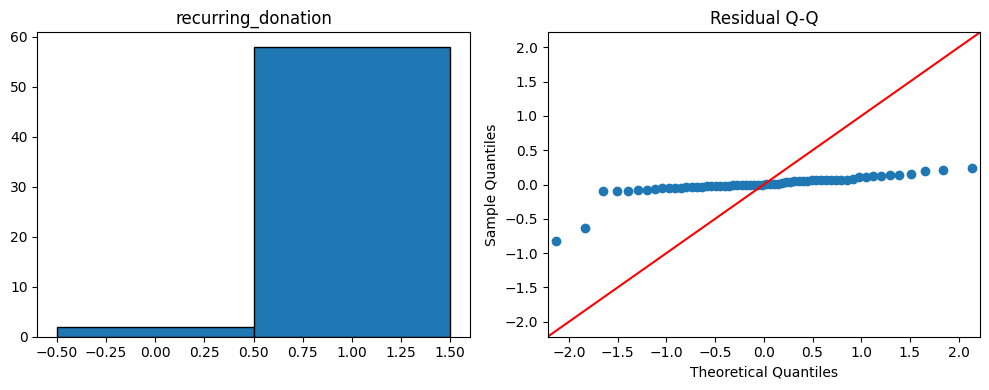

In [5]:
from statsmodels.stats.stattools import jarque_bera

print("Label skew:", float(pd.Series(y).skew()), "Shapiro p (subsample):", shapiro_tail(y)[1])
print("Residual JB:", jarque_bera(m0.resid))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(y, bins=np.arange(-0.5, 2, 1), edgecolor="k")
ax[0].set_title("recurring_donation")
sm.qqplot(m0.resid, line="45", ax=ax[1])
ax[1].set_title("Residual Q-Q")
plt.tight_layout()
plt.show()


## 4) Multicollinearity (VIF) and iterative removal
We remove features with **VIF > 7** one at a time, then refit.

In [6]:
Xv, removed = remove_high_vif_one_at_a_time(X, y)
print("Removed due to VIF:", len(removed))

m_vif, _ = ols_fit(Xv, y)
print(m_vif.summary())


Removed due to VIF: 2
                            OLS Regression Results                            
Dep. Variable:     recurring_donation   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                 -0.045
Method:                 Least Squares   F-statistic:                    0.8422
Date:                Tue, 07 Apr 2026   Prob (F-statistic):              0.634
Time:                        13:56:02   Log-Likelihood:                 26.095
No. Observations:                  60   AIC:                            -18.19
Df Residuals:                      43   BIC:                             17.41
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

/Users/mckayyorgason/Library/Python/3.12/lib/python/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


## 5) Refinement: interaction effects
We add a theory-driven interaction: `acquisition_channel_SocialMedia × supporter_type_SocialMediaAdvocate` (if present).

                            OLS Regression Results                            
Dep. Variable:     recurring_donation   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                 -0.052
Method:                 Least Squares   F-statistic:                    0.8297
Date:                Tue, 07 Apr 2026   Prob (F-statistic):              0.652
Time:                        13:56:02   Log-Likelihood:                 26.603
No. Observations:                  60   AIC:                            -17.21
Df Residuals:                      42   BIC:                             20.49
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

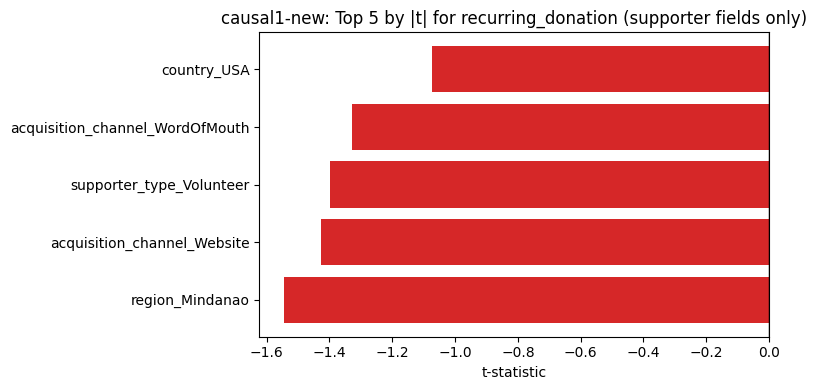

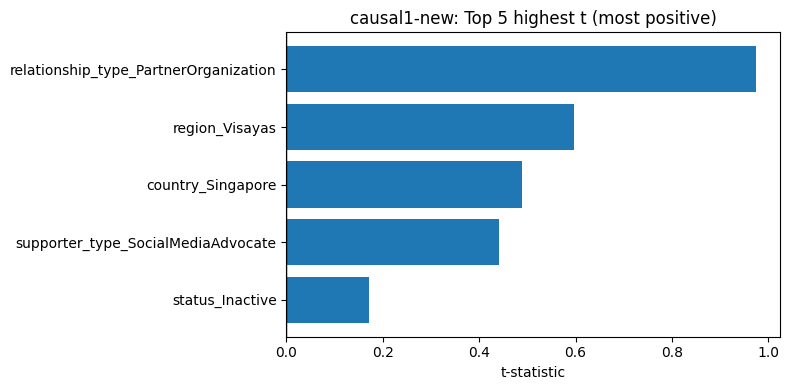

In [7]:
Xr = Xv.copy()

ch_soc = [c for c in Xr.columns if c.startswith("acquisition_channel_") and "SocialMedia" in c]
typ_adv = [c for c in Xr.columns if c.startswith("supporter_type_") and "SocialMediaAdvocate" in c]
if ch_soc and typ_adv:
    Xr["social_channel_x_advocate"] = Xr[ch_soc[0]] * Xr[typ_adv[0]]

Xr, _ = remove_high_vif_one_at_a_time(Xr, y)
m_final, _ = ols_fit(Xr, y)
print(m_final.summary())

# Top 5 by |t|
plot_top_t(m_final, k=5, title="causal1-new: Top 5 by |t| for recurring_donation (supporter fields only)")

# Top 5 by highest (most positive) t
plot_top_t_positive(m_final, k=5, title="causal1-new: Top 5 highest t (most positive)")


## Interpretation & limitations
- Coefficients represent **associations**, not proof that a channel/type causes recurring behavior.
- The label uses donation history by definition; predictors here are **supporter fields only**, so this view answers “which supporter segments are associated with recurring behavior?”
- For predictive classification, consider logistic regression + train/test evaluation (Ch. 11), but this notebook focuses on Chapter 10 diagnostics and explanatory framing.


## 3. Modeling & Feature Selection

We start with an initial OLS model, then improve interpretability/stability using label transformations (when appropriate) and multicollinearity reduction via **VIF** (dropping features with VIF > 7 one-at-a-time). We also include one interaction term tied to the business question.

## 4. Evaluation & Interpretation

### Key evaluation reality: the label is extremely imbalanced
In this dataset, the **recurring rate is very high** (almost everyone is labeled `recurring_donation = True`). That makes it hard for any model to reliably separate “recurring” vs “not recurring.” In plain terms: there aren’t enough examples of *non-recurring* supporters to learn stable patterns.

### What we evaluate in an explanatory (non-predictive) notebook
- **Diagnostics**: residual checks and multicollinearity (VIF removal > 7).
- **Stability**: whether the same features remain important after VIF cleanup and minor modeling choices.
- **Interpretability**: whether the relationships make business sense.

### What the top t-scores were (and what they mean)
The highest positive t-scores in the refined model were:
- **`relationship_type_PartnerOrganization`**
- **`region_Visayas`**
- **`country_Singapore`**
- **`supporter_type_SocialMediaAdvocate`**
- **`status_Inactive`**

**Business interpretation (with the right caution):**
- A positive t-score for **`relationship_type_PartnerOrganization`** suggests that supporters categorized with a partner-organization relationship were *more likely* to be recurring **in this sample**, compared to the baseline relationship group.
- Region/country indicators (like **Visayas** or **Singapore**) can reflect **where** recurring supporters are concentrated, but they often stand in for other unobserved differences (campaigns, partnerships, reporting practices).

### Why you should not over-interpret this model
Because `recurring_donation` is nearly always True, the “top” t-scores here can be driven by small sample quirks rather than real business mechanisms. Treat these as **hypotheses**, not conclusions.

If you want stronger insight, common fixes are:
- Redefine “recurring” with a **time window** (e.g., 2+ donations within 12 months),
- Ensure enough **non-recurring** examples,
- Or analyze an explanatory target with more variation (e.g., number of donations, total value).

## 5. Causal and Relationship Analysis

### What relationships appear strongest?
The model’s strongest positive signals were categorical “segment” indicators (relationship type, region, country, supporter type). The most notable was:
- **`relationship_type_PartnerOrganization`** (highest positive t-score)

### What that could mean in business terms
If this relationship is real (not just noise from an imbalanced label), a plausible story is:
- Partner organizations may have **ongoing commitments** (standing agreements, recurring transfers, periodic in-kind support), which would naturally show up as “recurring.”

This would suggest practical actions like:
- Designing partner-specific stewardship (scheduled updates, reporting packages, renewal reminders).

### Why causality is not established here
We cannot say “being a partner organization causes recurring giving,” because:
- **Selection effects**: partner organizations are defined by the relationship itself; they likely differ systematically from individual donors.
- **Measurement effects**: recurring may be recorded differently across segments.
- **Imbalanced outcome**: with very few non-recurring supporters, the model’s ranking of features is unstable.

### What would strengthen the causal story
- **Time-based definition** of recurring giving (so we’re predicting a future behavior rather than re-describing history).
- A design that compares similar supporters (matching / stratification) or uses experiments (different stewardship messages, cadence, content).

## 6. Deployment Notes

These notebooks are designed to be run end-to-end by a TA. For the deployed web app, the *intended* integration is to surface the key model outputs (top relationships, coefficient directions, and diagnostics) in dashboards or admin views.

If your app currently has an `artifacts/` or model-output folder, you can export summary tables/figures there from this notebook (e.g., coefficient tables as CSV). If integration code isn’t yet in the repo, keep this section honest and describe the planned endpoint/component that will display results.